# Exploring ML Algorithms on California Housing Data

**Elements of Artificial Intelligence, AGH 2026**

**Author:** Jakub Gołąb


# Table of Contents

1. [Introduction](#sekcja-intro)
2. [Methodology](#sekcja-meth)
3. [Setup](#sekcja-setup)
4. [EDA](#sekcja-eda)
5. [Random Forest](#sekcja-rf)
6. [Gradient Boosting](#sekcja-gb)
7. [KNN](#sekcja-knn)
8. [SVR](#sekcja-svr)
9. [Discussion](#sekcja-disc)
10. [Conclusion](#sekcja-conc)

# <a id="sekcja-intro"></a>1. Introduction

**Research Goal**

The primary objective of this project is to explore, implement, and evaluate various Machine Learning algorithms. To conduct this research, we utilize the California Housing Dataset as our practical foundation. While this dataset - derived from the 1990 U.S. Census - provides essential metrics such as median income, housing age, and location, its main purpose here is to serve as a robust testing ground for training and comparing the performance of different predictive models.

Furthermore, this notebook is designed with an educational purpose in mind. Each applied algorithm is accompanied by a theoretical introduction. This approach aims to deepen the reader's understanding of the underlying mechanics and make the content fully accessible, even to those with limited ML experience.

# <a id="sekcja-meth"></a>2. Methodology

**Data Source & Origin:**

The primary dataset used in this research is the California Housing Data, originally introduced in the study:

`Pace, R. Kelley, and Ronald Barry. "Sparse spatial autoregressions." Statistics & Probability Letters 33.3 (1997)`

However, dataset used in this research was fetched from [Kaggle.com](https://www.kaggle.com/datasets/fedesoriano/california-housing-prices-data-extra-features/data). Author enriched it with 5 variables - "Distance_to_coast" and distances to the centres of the largest cities in California.


**Analytical Framework:**

The methodology of this project is built upon three pillars:

* Industry Standards: The workflow (Data Cleaning, Feature Engineering, Model Selection) follows the best practices gained during the *IBM Data Science Professional Certification* and coursework *Elements of Artificial Intelligence* at AGH University.

* Comparative Analysis: My results and model performances will be benchmarked against existing high-performing notebooks on Kaggle to ensure competitive accuracy.

* LLM-Assisted Validation: To maintain high code quality and methodological rigor, the approaches and feature selection were cross-checked and optimized using Large Language Models (Gemini 3 Pro and Claude 3.5).

# <a id="sekcja-setup"></a>3. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import sys
import os
import branca.colormap as cm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# for google colab: 
if 'google.colab' in sys.modules or os.path.exists('/content'):
    if not os.path.exists('/content/NEURALENJOYERS'):
        token=""
        os.system(f'git clone https://{token}@github.com/Projekty-IiE/NeuralEnjoyers.git /content/NEURALENJOYERS')
    else:
        os.system('git -C /content/NEURALENJOYERS pull')
    sys.path.insert(0, '/content/NEURALENJOYERS/Klasyfikacyjny')
    os.chdir('/content/NEURALENJOYERS')


## Fetching data

In [3]:
df = pd.read_csv("ML_Regression/California_Houses.csv")
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


Before we dive into the exploratory data analysis and train our machine learning models, it is crucial to clarify exactly what our data represents. A common pitfall when looking at this dataset is assuming that each row corresponds to a single, specific house. This is not the case.

Due to privacy protocols in the US Census, data is aggregated into geographic areas called block groups (or simply "blocks"). A block typically contains between 600 and 3,000 people. Therefore, every row in our dataset represents the aggregate statistics for an entire neighborhood, not an individual property or family.

## Additional Experiment Function

This function will be used across our models to assist with testing of 4 values for a specific parameter and plotting Train vs Test scores.

In [4]:
def run_sklearn_experiment(model, param_name, param_values, X_train, y_train, cv=5):
    """
    Runs GridSearchCV for a single parameter to isolate its impact, 
    extracts the results, and plots the Train vs. Validation R2 scores.
    """
    print(f"Testing {param_name} with values: {param_values}...")
    
    # Setup the grid for just this one parameter
    param_grid = {param_name: param_values}
    
    # Run GridSearch. return_train_score=True is REQUIRED to analyze overfitting
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='r2', 
        return_train_score=True,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    # Extract the results into a clean Pandas DataFrame
    results_df = pd.DataFrame(grid.cv_results_)
    
    summary_df = pd.DataFrame({
        'Value': results_df[f'param_{param_name}'],
        'Train_R2': results_df['mean_train_score'],
        'Test_R2': results_df['mean_test_score']
    })
    
    # Draw the Plot
    plt.figure(figsize=(8, 5))
    plt.plot(summary_df['Value'], summary_df['Train_R2'], marker='o', label='Training Set')
    plt.plot(summary_df['Value'], summary_df['Test_R2'], marker='s', label='Cross-Validation (Test) Set')
    
    plt.title(f'Impact of {param_name} on Model Accuracy')
    plt.xlabel(param_name)
    plt.ylabel('R-squared Score')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    summary_df.to_csv(f"sklearn_experiment_{param_name}.csv", index=False)

    return summary_df

# <a id="sekcja-eda"></a>4. EDA

In [5]:
def df_check(df):
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Unique Values': df.nunique(),
        'Missing Values': df.isnull().sum()})
    
    return summary.reset_index().rename(columns={'index': 'Column Name'})


df_check(df)

,Column Name,Data Type,Unique Values,Missing Values
0,Median_House_Value,float64,3842,0
1,Median_Income,float64,12928,0
2,Median_Age,int64,52,0
3,Tot_Rooms,int64,5926,0
4,Tot_Bedrooms,int64,1928,0
5,Population,int64,3888,0
6,Households,int64,1815,0
7,Latitude,float64,862,0
8,Longitude,float64,844,0
9,Distance_to_coast,float64,12590,0


In [6]:
df.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928682,117395.477505
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019101,1.736675e+05,2.147398e+05,459758.877000,526546.661701
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414479,5.271562e+05,7.057954e+05,516946.490963,584552.007907
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298


### Feature engineering

During the initial data exploration, a critical issue was identified with several features:

 *Tot_Rooms, Tot_Bedrooms, Population, and Households*. These variables represent cumulative, absolute totals for an entire census block.

Relying on absolute totals introduces a fundamental bias into the data: a neighborhood with 1,000 small apartments will naturally have a higher *Tot_Rooms* count than an exclusive neighborhood with 10 luxury mansions. Consequently, these raw totals act primarily as a measure of a block's geographic or demographic size, rather than an indicator of the actual wealth or structural characteristics of a typical home in that area.

To resolve this and provide the models with meaningful data, these totals were converted into normalized ratios:

**Rooms_per_Household** (*Tot_Rooms / Households*): This reveals the average size of a home in the block. A higher ratio strongly correlates with larger, more expensive properties, rather than densely packed apartments.

**Bedrooms_per_Room** (*Tot_Bedrooms / Tot_Rooms*): This measures the utility and density of the floor plan. A higher percentage of bedrooms often indicates multi-family units or lower-income housing, whereas luxury homes typically have a lower ratio due to the presence of large living rooms, dining rooms, and studies.

**Population_per_Household** (*Population / Households*): This metric estimates the average family size or crowding within the neighborhood, providing insight into the area's demographic profile.

In [7]:
df_engineered = df.copy()

# 2. Engineer the new, highly predictive ratios using your exact column names
df_engineered['Rooms_per_Household'] = df_engineered['Tot_Rooms'] / df_engineered['Households']
df_engineered['Bedrooms_per_Room'] = df_engineered['Tot_Bedrooms'] / df_engineered['Tot_Rooms']
df_engineered['Population_per_Household'] = df_engineered['Population'] / df_engineered['Households']

# 3. Drop the old absolute totals that were confusing the model
columns_to_drop = ['Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households']
df_engineered = df_engineered.drop(columns=columns_to_drop)
df_engineered.head()

,Median_House_Value,Median_Income,Median_Age,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,Rooms_per_Household,Bedrooms_per_Room,Population_per_Household
0,452600.0,8.3252,41,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767,6.984127,0.146591,2.555556
1,358500.0,8.3014,21,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400,6.238137,0.155797,2.109842
2,352100.0,7.2574,52,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450,8.288136,0.129516,2.802260
3,341300.0,5.6431,52,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568,5.817352,0.184458,2.547945
4,342200.0,3.8462,52,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568,6.281853,0.172096,2.181467


### The Outlier Problem

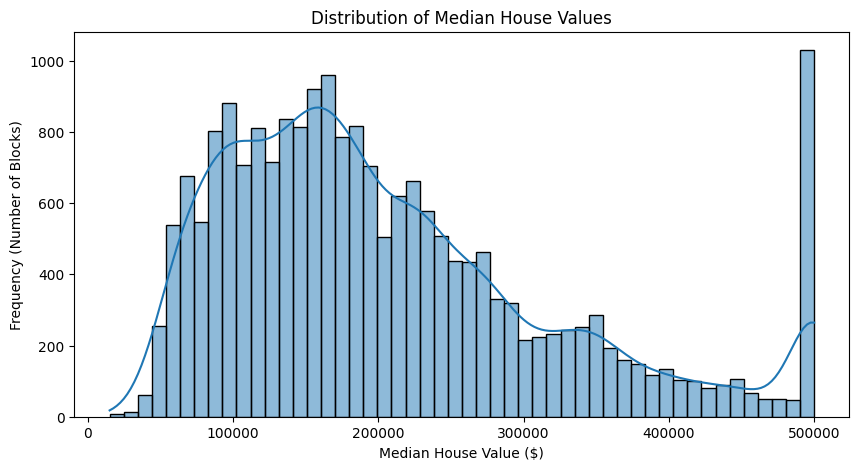

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_engineered['Median_House_Value'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency (Number of Blocks)')
plt.show()

Looking at the far right of the histogram, there is a massive, unnatural spike exactly at the $500,001 mark.

This isn't a coincidence. During the original census, any neighborhood with a median value higher than half a million dollars was artificially capped at $500,001. This means a standard family home on the coast and a massive Hollywood mansion were lumped into the exact same "data bucket" and given the exact same price tag.

If we feed this capped data to our machine learning models, it will deeply confuse them. The algorithms will struggle to learn the mathematical rules of the market if vastly different properties are artificially priced the same.

As this research is mostly focused on applying ML algorithms, to fix this, we will simply drop households above 500,000$.

In [9]:
df_clean = df_engineered[df_engineered['Median_House_Value'] < 500001].copy()

dropped_rows = df_engineered.shape[0] - df_clean.shape[0]
dropped_rows

965

Only ~5% of data was lost.

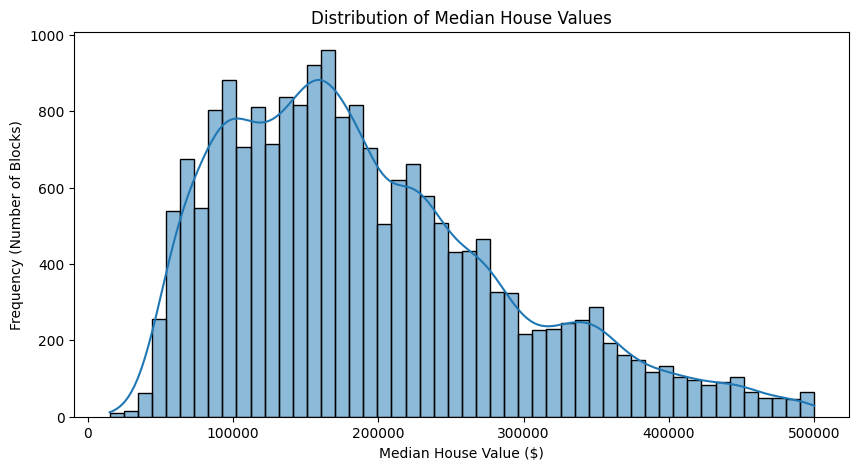

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Median_House_Value'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency (Number of Blocks)')
plt.show()

Now target value looks much "healthier".


### Folium Map

In [11]:
df_sample = df_clean.sample(n=2000, random_state=67)

min_val = df_sample['Median_House_Value'].min()
max_val = df_sample['Median_House_Value'].max()

colormap = cm.LinearColormap(
    colors=['blue', 'green', 'yellow', 'red'], 
    vmin=min_val, 
    vmax=max_val,
    caption='Median House Value ($)')

california_map = folium.Map(location=[36.7783, -119.4179], zoom_start=6, tiles='CartoDB positron')

for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=colormap(row['Median_House_Value']),
        fill=True,
        fill_color=colormap(row['Median_House_Value']),
        fill_opacity=0.7,
        tooltip=f"Value: ${row['Median_House_Value']:,.0f}" 
    ).add_to(california_map)

california_map.add_child(colormap)
california_map




### Correlation between variables

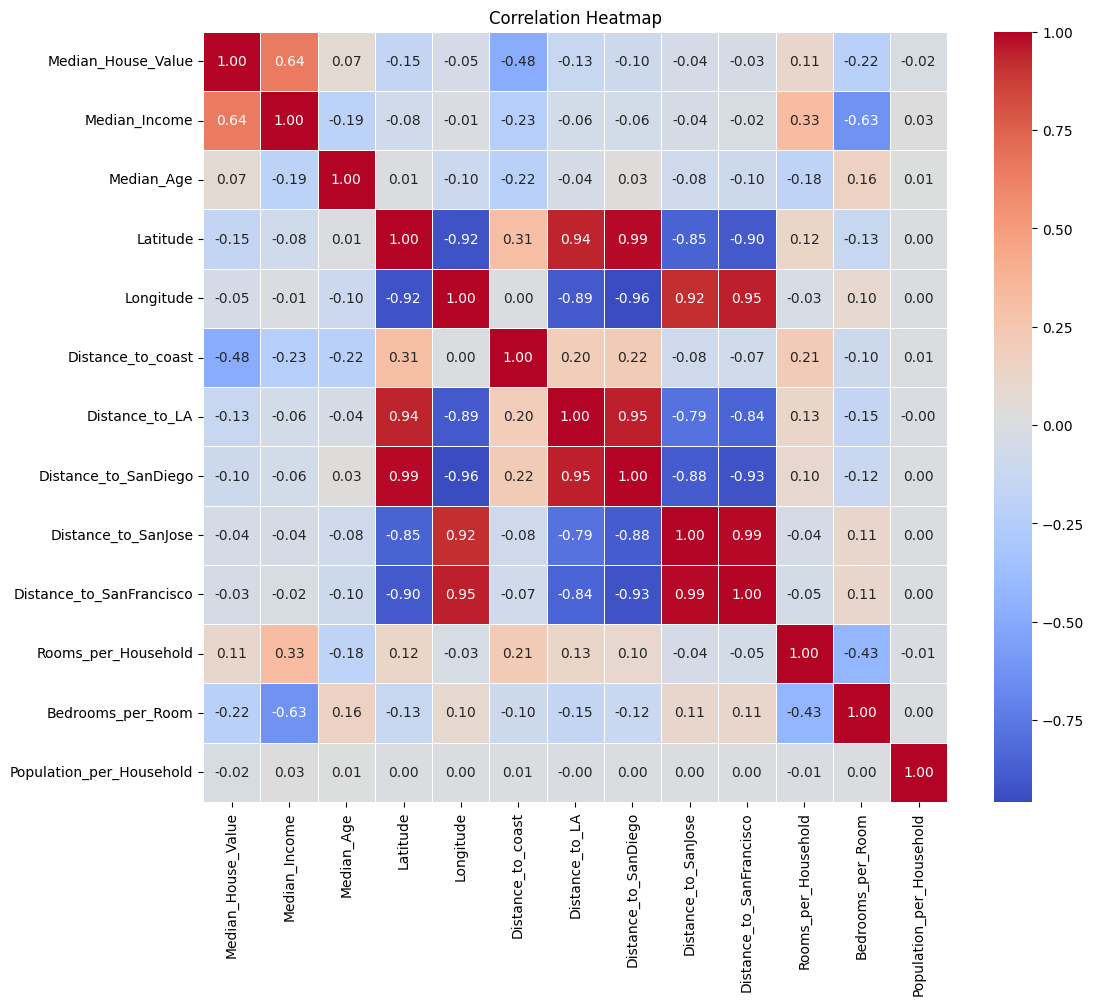

In [12]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [13]:
correlations_with_price = correlation_matrix['Median_House_Value'].sort_values(ascending=False)
corr_pd = correlations_with_price.reset_index()
corr_pd.columns = ["Variable","Correlation with Target var."]
corr_pd

,Variable,Correlation with Target var.
0,Median_House_Value,1.000000
1,Median_Income,0.642611
2,Rooms_per_Household,0.109673
3,Median_Age,0.067948
4,Population_per_Household,-0.021465
5,Distance_to_SanFrancisco,-0.032345
6,Distance_to_SanJose,-0.043581
7,Longitude,-0.046658
8,Distance_to_SanDiego,-0.096135
9,Distance_to_LA,-0.131000


# <a id="sekcja-rf"></a>5. Random Forest Regressor

## 5.1 How does Random Forest Regressor work?


A single decision tree can easily make mistakes. Random forests create an entire army of them (e.g. 100 trees). Each tree gets a slightly different, random subset of data and a random set of columns to work with (Bootstraping). In the end, all the trees vote on the final value. This drastically reduces the errors of a single tree (*the wisdom of the crowd*).

Because Random Forests don't need scaled data, we are going to train it on the raw, unscaled X_train. This is a huge advantage because later on, when we look at the results, the numbers will still be in real-world units (meters, dollars, years) instead of confusing standardized decimals!

## 5.2 Model Development

### Train-test split

In [14]:
# 1. Define what we are trying to predict (y) and the data we use to predict it (X)
y = df_clean['Median_House_Value']
X = df_clean.drop(columns=['Median_House_Value'])

# 2. The Golden Split
# test_size=0.2 means 20% of the neighborhoods are locked away for the "Final Exam"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

print("Data successfully split!")
print(f"Training data (The Textbook): {X_train.shape[0]} blocks")
print(f"Testing data (The Final Exam):  {X_test.shape[0]} blocks")

Data successfully split!
Training data (The Textbook): 15740 blocks
Testing data (The Final Exam):  3935 blocks


### Training

**Key parameter**:

*n_estimators*: The number of trees in the forest (the more, the more stable the model, but the slower it trains).

In [15]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=67, n_jobs=-1)

print("Planting 100 decision trees and learning the California market...")
rf_model.fit(X_train, y_train)
print("Training complete! The Forest is ready.")

Planting 100 decision trees and learning the California market...
Training complete! The Forest is ready.


### Evaluation

Now we take our *X_test* data (the 20% of neighborhoods the model has never seen) and ask it for a price. The data for one neighborhood is passed to all 100 trees. Tree 1 predicts 200,000 USD. Tree 2 predicts 215,000 USD. Tree 100 predicts 195,000 USD. The Random Forest takes the average of all 100 predictions and presents that as the final answer.

In [16]:
rf_predictions = rf_model.predict(X_test)

# Calculate the errors
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
print(f"This means our model's valuation is off by an average of ${mae:,.0f} per neighborhood.")
print(f"R-squared Score: {r2:.4f} (1.0 is a perfect score)")

Mean Absolute Error (MAE): $27,283
This means our model's valuation is off by an average of $27,283 per neighborhood.
R-squared Score: 0.8089 (1.0 is a perfect score)


### Diving into the black box - Feature Importance

One of the greatest things about Random Forests is that they aren't totally opaque. Because the algorithm had to split the data millions of times across 100 trees, it kept a tally. It knows exactly which features (like Income or Distance to LA) resulted in the biggest, most mathematically pure splits in the data.

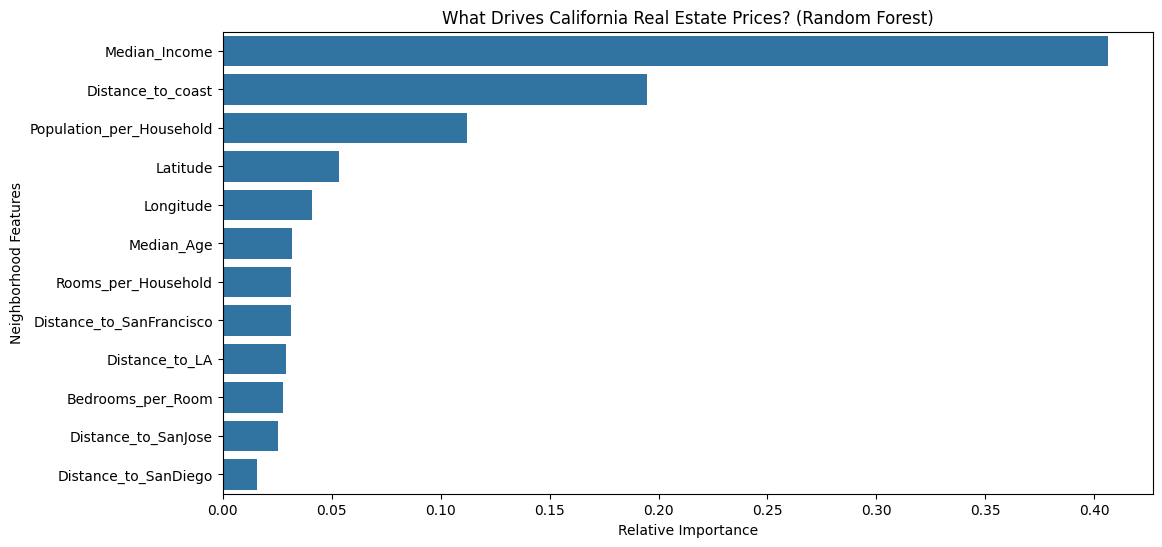

In [17]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('What Drives California Real Estate Prices? (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Neighborhood Features')
plt.show()

## 5.3 Model Improvment

Grid Search combined with K-fold cross-validation will be used to find the most suitable parameters.

For every single combination of settings, K-Fold chops X_train data into 5 pieces. It trains the forest on 4 pieces and tests it on the 5th. It does this 5 times, rotating the test piece, and takes the average score, which reduces the variance. This proves that the forest didn't just get lucky - it is genuinely good.

Analyzing the impact of n_estimators (Number of Trees)...
Testing n_estimators with values: [10, 50, 100, 200]...


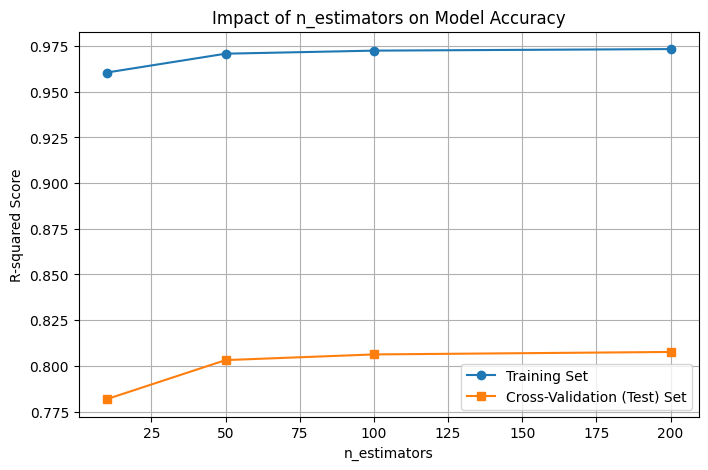

,Value,Train_R2,Test_R2
0,10,0.960476,0.781803
1,50,0.970770,0.803131
2,100,0.972442,0.806232
3,200,0.973292,0.807584


In [18]:
""" # n_estimators: Number of trees
# max_depth: How deep the trees can grow (None means they grow until they are pure)
# min_samples_split: Minimum number of houses required to split a node further
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=67)

# cv=5 means 5-fold cross-validation (5 practice exams per combination)
# n_jobs=-1 uses all your CPU cores
# scoring='neg_mean_absolute_error' tells it to look for the lowest dollar error
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5, 
    n_jobs=-1, 
    scoring='neg_mean_absolute_error',
    verbose=2 # This prints out updates so you don't think your computer froze
)

print("Starting the Grid Search... this might take a minute or two!")
# 4. Run the grueling tests on the training data ONLY
grid_search.fit(X_train, y_train)

# 5. The Results
print("\n--- RESULTS ---")
print("Best Settings Found:")
print(grid_search.best_params_)

# Extract the absolute best model from the search
best_rf_model = grid_search.best_estimator_ 

print("--- TESTING THE OPTIMIZED MODEL ---")

# 1. Ask the optimized model to predict prices for the unseen Test set
# Note: 'best_rf_model' was saved automatically in the previous Grid Search cell!
final_predictions = best_rf_model.predict(X_test)

# 2. Calculate the metrics by comparing predictions to the actual hidden prices (y_test)
mae = mean_absolute_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

# 3. Print the official final report
print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
print(f"R-squared (R^2) Score: {r2:.4f} / 1.0000")"""

from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=67)

print("Analyzing the impact of n_estimators (Number of Trees)...")
rf_results = run_sklearn_experiment(
model=rf_base,
param_name='n_estimators',
param_values=[10, 50, 100, 200],
X_train=X_train,
y_train=y_train
)

display(rf_results)


For this specific dataset, 50 to 100 trees seems to be the optimal spot. Increasing the number of trees from 50 to 200 resulted in only a microscopic (~0,004) R-squared improvement.

# <a id="sekcja-gb"></a>6. Gradient Boosting Regressor

## 6.1 How does Gradient Boosting Regressor work?

This is the reigning champion of tabular data. It works sequentially. It builds the first, very simple little tree. It then calculates the residual errors - specifically identifying which housing blocks or neighborhoods the initial model mispriced the most. The second tree learns only from the mistakes of the first one. The third fixes the mistakes of the second, and so on. This creates a highly robust, self-correcting ensemble model capable of capturing complex nuances in the real estate market.


## 6.2 Model Development

**The Key Parameters:**

* *n_estimators:* The number of correction stages (trees).
* *learning_rate:* How heavily we weight the corrections of each new tree. A smaller learning rate (like 0.1) prevents the model from overcorrecting and going crazy, but it means you need more trees to reach the final answer.
* *max_depth:* Unlike Random Forests which use massive, infinitely deep trees, Gradient Boosting uses very shallow trees (usually a depth of 3 to 5). It relies on teamwork, not individual tree complexity.

In [19]:

# 1. Initialize the model with strong baseline settings
# We use shallow trees (max_depth=5) but a lot of them (n_estimators=300)
# learning_rate=0.1 is the industry standard starting point
gbr_model = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=67
)

print("Building sequential trees and correcting errors (this takes a moment)...")
gbr_model.fit(X_train, y_train)

# 2. Final Exam for Gradient Boosting
gbr_preds = gbr_model.predict(X_test)
gbr_mae = mean_absolute_error(y_test, gbr_preds)
gbr_r2 = r2_score(y_test, gbr_preds)

print(f"\n--- RESULTS ---")
print(f"Gradient Boosting MAE:          ${gbr_mae:,.0f}")
print(f"Gradient Boosting R^2 Score:    {gbr_r2:.4f}")

Building sequential trees and correcting errors (this takes a moment)...

--- RESULTS ---
Gradient Boosting MAE:          $26,734
Gradient Boosting R^2 Score:    0.8223


## 6.3 Model Improvment

Analyzing the impact of max_depth (Complexity of individual trees)...
Testing max_depth with values: [2, 3, 5, 8]...


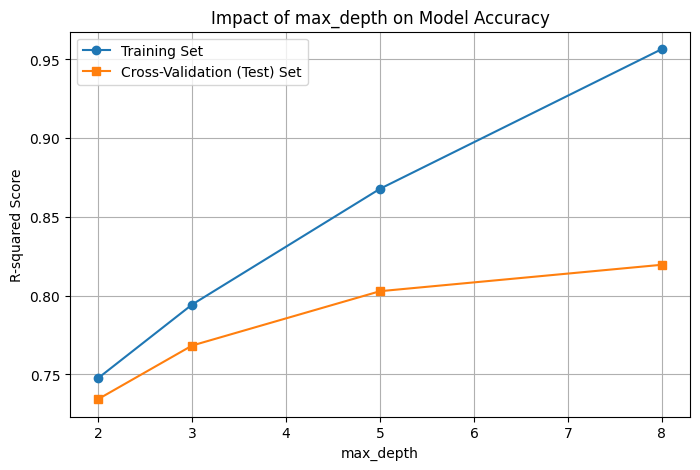

,Value,Train_R2,Test_R2
0,2,0.747667,0.734341
1,3,0.794368,0.768339
2,5,0.867847,0.802832
3,8,0.956529,0.819607


In [20]:
""" param_grid_gbr = {
    'n_estimators': [200, 300, 400],    # How many correction steps?
    'learning_rate': [0.05, 0.1],       # Slow and steady vs. Fast and aggressive
    'max_depth': [4, 5, 6]              # Depth of the individual trees
}

gbr_base = GradientBoostingRegressor(random_state=42)

# 2. Set up the Grid Search
# cv=3 means 3 practice exams (folds) per combination to keep training time reasonable
# n_jobs=-1 will still help by running the different cross-validation folds in parallel
grid_search_gbr = GridSearchCV(
    estimator=gbr_base, 
    param_grid=param_grid_gbr, 
    cv=3, 
    n_jobs=-1, 
    scoring='neg_mean_absolute_error',
    verbose=2
)

print("Starting Grid Search for Gradient Boosting...")
print("Testing 18 combinations with 3 folds each (54 total fits). Hang tight!")

# 3. Train the combinations
grid_search_gbr.fit(X_train, y_train)

# 4. The Results
print("\n--- TUNING RESULTS ---")
print("Best Settings Found:")
print(grid_search_gbr.best_params_)

# 5. The Final Exam for the Best GBR
best_gbr_model = grid_search_gbr.best_estimator_
tuned_gbr_preds = best_gbr_model.predict(X_test)

tuned_gbr_mae = mean_absolute_error(y_test, tuned_gbr_preds)

print("-" * 30)
print(f"Tuned GBR MAE:          ${tuned_gbr_mae:,.0f}") """

from sklearn.ensemble import GradientBoostingRegressor

gbr_base = GradientBoostingRegressor(random_state=67, n_estimators=100)

print("Analyzing the impact of max_depth (Complexity of individual trees)...")
gbr_results = run_sklearn_experiment(
model=gbr_base,
param_name='max_depth',
param_values=[2, 3, 5, 8],
X_train=X_train,
y_train=y_train
)

display(gbr_results)

At a shallow depth of 2, the model slightly underfits the data, resulting in the lowest scores. Increasing the tree depth to 5 provides a strong improvement. Pushing the depth to 8 is where the model shows classic overfitting. The gap between Train and Test results widens drastically. 

## 6.4 Random Forest vs Gradient Boosting Comparison 

--- VISUALIZING MODEL PERFORMANCE ---


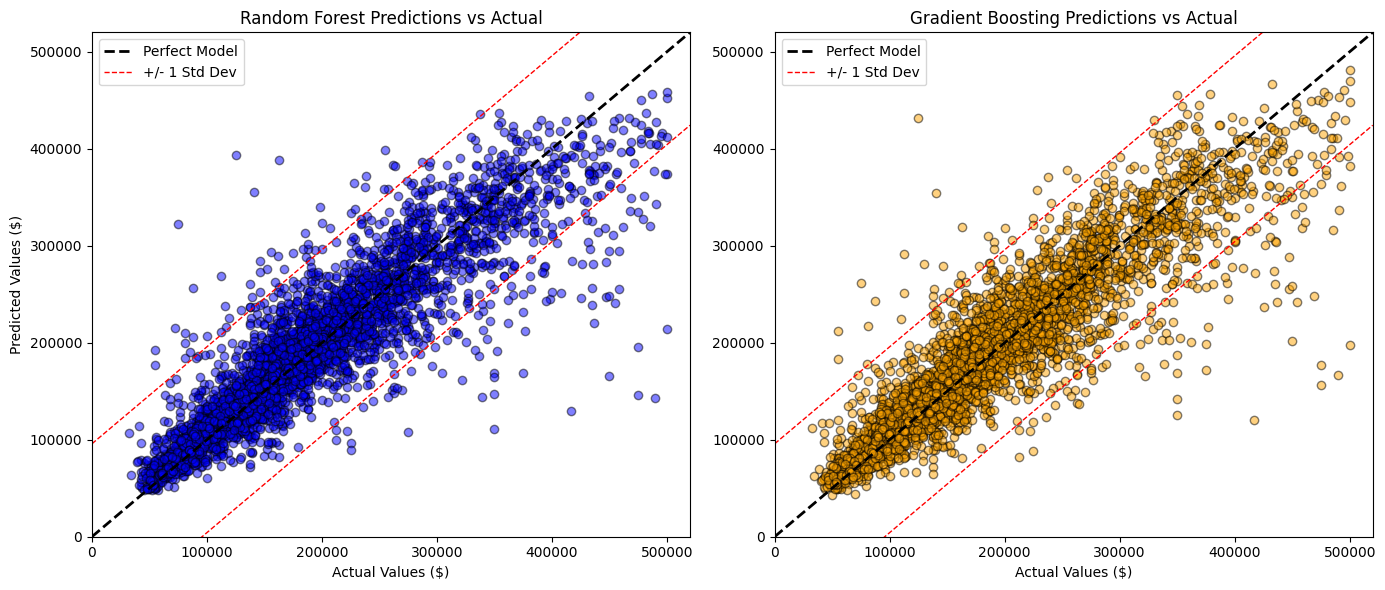

In [21]:
""" print("--- VISUALIZING MODEL PERFORMANCE ---")

# Calculate the standard deviation of the actual prices
std_y = y_test.std()

# Define the minimum and maximum boundaries for our plot axes
# We add a $20,000 buffer to the max so the points don't touch the very edge of the graph
min_val = 0
max_val = y_test.max() + 20000 

plt.figure(figsize=(14, 6))

# ---------------------------------------------------------
# Plot 1: Random Forest
# ---------------------------------------------------------
plt.subplot(1, 2, 1)
plt.scatter(y_test, final_predictions, alpha=0.5, color="blue", ec='k')

# The "Perfect Model" diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Model")

# The +/- 1 Standard Deviation lines
plt.plot([min_val, max_val], [min_val + std_y, max_val + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([min_val, max_val], [min_val - std_y, max_val - std_y], 'r--', lw=1)

# Formatting
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values ($)")
plt.ylabel("Predicted Values ($)")
plt.legend(loc="upper left")

# ---------------------------------------------------------
# Plot 2: Gradient Boosting
# ---------------------------------------------------------
plt.subplot(1, 2, 2)
plt.scatter(y_test, tuned_gbr_preds, alpha=0.5, color="orange", ec='k')

# The "Perfect Model" diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Model")

# The +/- 1 Standard Deviation lines
plt.plot([min_val, max_val], [min_val + std_y, max_val + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([min_val, max_val], [min_val - std_y, max_val - std_y], 'r--', lw=1)

# Formatting
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("Gradient Boosting Predictions vs Actual")
plt.xlabel("Actual Values ($)")
# We can skip the ylabel here since it shares the same scale as the left plot
plt.legend(loc="upper left")

plt.tight_layout()
plt.show() """

## 6.4 Random Forest vs Gradient Boosting Comparison 
print("--- VISUALIZING MODEL PERFORMANCE ---")

# Calculate the standard deviation of the actual prices
std_y = y_test.std()

# Define the minimum and maximum boundaries for our plot axes
min_val = 0
max_val = y_test.max() + 20000 

plt.figure(figsize=(14, 6))

# ---------------------------------------------------------
# Plot 1: Random Forest
# ---------------------------------------------------------
plt.subplot(1, 2, 1)
# Using rf_predictions from our baseline model in Section 5.2
plt.scatter(y_test, rf_predictions, alpha=0.5, color="blue", ec='k')

# The "Perfect Model" diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Model")

# The +/- 1 Standard Deviation lines
plt.plot([min_val, max_val], [min_val + std_y, max_val + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([min_val, max_val], [min_val - std_y, max_val - std_y], 'r--', lw=1)

# Formatting
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values ($)")
plt.ylabel("Predicted Values ($)")
plt.legend(loc="upper left")

# ---------------------------------------------------------
# Plot 2: Gradient Boosting
# ---------------------------------------------------------
plt.subplot(1, 2, 2)
# Using gbr_preds from our baseline model in Section 6.2
plt.scatter(y_test, gbr_preds, alpha=0.5, color="orange", ec='k')

# The "Perfect Model" diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Model")

# The +/- 1 Standard Deviation lines
plt.plot([min_val, max_val], [min_val + std_y, max_val + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([min_val, max_val], [min_val - std_y, max_val - std_y], 'r--', lw=1)

# Formatting
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("Gradient Boosting Predictions vs Actual")
plt.xlabel("Actual Values ($)")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()


# <a id="sekcja-knn"></a>7. KNN Regressor

While tree-based algorithms like Random Forest and Gradient Boosting rely on constructing complex, hierarchical rules to predict housing prices, the K-Nearest Neighbors (KNN) Regressor takes a fundamentally different, geometry-based approach. KNN operates on a simple, intuitive premise: properties with similar characteristics should have similar values.

Often categorized as a "lazy learning" algorithm, KNN does not mathematically derive an underlying function or build an internal model during the training phase. Instead, it effectively memorizes the entire training dataset. When tasked with predicting the median house value for a new, unseen neighborhood, the algorithm maps the new data point into a multi-dimensional space and calculates its mathematical distance to all existing points in the training set.

The model then identifies the 'K' closest data points - its "nearest neighbors." The final price prediction is generated by averaging the target values of these specific neighbors.

To ensure the algorithm functions correctly, particularly in real estate datasets containing a mix of diverse metrics (such as single-digit income levels alongside distances measured in hundreds of thousands of meters), **data standardization is required**. 
Without scaling, features with massive numerical ranges would disproportionately dominate the distance calculations, blinding the model to smaller, yet highly predictive, variables. By standardizing the data and optimizing the 'K' parameter, KNN serves as a powerful, distance-based benchmark for market valuation.

--- 3. K-NEAREST NEIGHBORS (KNN) ---
Data successfully standardized for distance calculations.

Analyzing the impact of n_neighbors (K)...
Testing n_neighbors with values: [3, 5, 10, 20]...


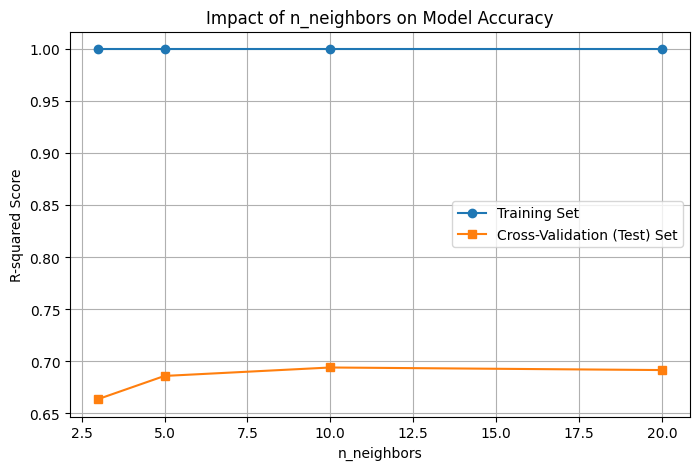

,Value,Train_R2,Test_R2
0,3,1.0,0.663803
1,5,1.0,0.686035
2,10,1.0,0.694146
3,20,1.0,0.691680


In [22]:
""" print("--- 3. K-NEAREST NEIGHBORS (KNN) ---")

# 1. The Scaling Imperative
# We MUST scale our engineered data so 'Income' and 'Distance' have equal weight
scaler_eng = StandardScaler()

# Remember the golden rule: fit_transform on train, ONLY transform on test!
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)
print("Data successfully standardized for distance calculations.")

# 2. Initialize the KNN Model
# We'll start with 7 neighbors and give closer neighbors more voting power
knn_model = KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1)

print("Memorizing the California housing market...")
knn_model.fit(X_train_eng_scaled, y_train_eng)

# 3. The Final Exam
knn_preds = knn_model.predict(X_test_eng_scaled)
knn_mae = mean_absolute_error(y_test_eng, knn_preds)
knn_r2 = r2_score(y_test_eng, knn_preds)

print(f"\n--- RESULTS ---")
print(f"KNN Mean Absolute Error (MAE): ${knn_mae:,.0f}")
print(f"KNN R^2 Score:                 {knn_r2:.4f}") """

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

print("--- 3. K-NEAREST NEIGHBORS (KNN) ---")

# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data successfully standardized for distance calculations.")

# Parameter Analysis: Number of Neighbors (K)
knn_base = KNeighborsRegressor(weights='distance')

print("\nAnalyzing the impact of n_neighbors (K)...")
knn_results = run_sklearn_experiment(
model=knn_base,
param_name='n_neighbors',
param_values=[3, 5, 10, 20],
X_train=X_train_scaled,
y_train=y_train
)

display(knn_results)

At K=3, the model is too sensitive to local noise, yielding the lowest Test R-squared. Expanding to K=5 provides optimal balance. However, pushing to K=10 causes performance to slightly dip, since the model takes into account neighbours that are too far away.  

# <a id="sekcja-svr"></a>8. Support Vector Regression (SVR)

While traditional linear regression attempts to draw a line that minimizes the total error across all data points, Support Vector Regression (SVR) flips this objective on its head. Instead of worrying about every single minor error, SVR constructs a theoretical "tube" (known as the $epsilon$-tube, or epsilon-tube) around the prediction line.

Any data point - or in this case, any neighborhood - whose actual price falls inside this tube is considered "accurate enough" and is mathematically ignored. The algorithm's sole focus is on the outliers: the points that fall outside the tube. These points are called the "Support Vectors," and the algorithm penalizes itself based on how far these specific points deviate from the acceptable margin.

Furthermore, real estate data is rarely strictly linear. To capture the complex realities of the housing market, SVR utilizes a mathematical technique called the "Kernel Trick" (most commonly the Radial Basis Function, or RBF). This transforms the data into a higher-dimensional space, allowing the algorithm to draw highly complex, non-linear boundaries to predict prices. Because SVR relies heavily on distance and spatial calculations in these higher dimensions, strict feature standardization is absolutely mandatory to prevent features with large numerical ranges (like distance to the coast) from dominating the model.

1. The Scaling Rule (Crucial)

Just like KNN, SVR will completely fail if the data isn't scaled. A distance of 100,000 meters to LA will crush a median income of 8. We will reuse the X_train_eng_scaled data we created in the KNN step.

2. Choosing the Kernel

If we chose kernel='linear', SVR would just draw a straight line. We will choose kernel='rbf' (Radial Basis Function). This tells the math to warp and bend to fit the complex, curved relationships of the California market.

3. The C Parameter (The Budget)

C is how strictly the model punishes errors outside the tube. A low C makes a very "chill" model that accepts a lot of errors. A high C makes a strict model that bends over backwards to capture every outlier. Because our prices are in the hundreds of thousands of dollars, we need a high C (like 100,000) so the model actually cares about a $10,000 error.

--- 4. SUPPORT VECTOR REGRESSION (SVR) ---
Analyzing the impact of the C parameter (Penalty for errors)...
Testing C with values: [1, 100, 10000, 100000]...


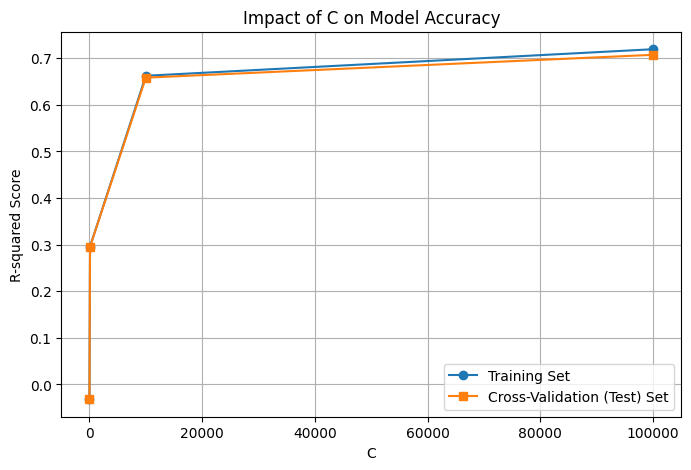

,Value,Train_R2,Test_R2
0,1,-0.031185,-0.031714
1,100,0.295929,0.295346
2,10000,0.662460,0.658448
3,100000,0.719477,0.707474


In [23]:
""" from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

print("--- 4. SUPPORT VECTOR REGRESSION (SVR) ---")

# 1. Initialize the SVR model
# kernel='rbf': Allows it to learn non-linear (curved) relationships
# C=100000: We set a high penalty for being wrong, appropriate for large dollar amounts
# epsilon=10000: We tell the model "If you guess within $10k of the true price, I consider it perfect."
svr_model = SVR(kernel='rbf', C=100000, epsilon=10000)

print("Mapping data to higher dimensions and calculating support vectors (this takes time)...")

# 2. Train the model (Using the SCALED data!)
svr_model.fit(X_train_eng_scaled, y_train_eng)

# 3. The Final Exam
print("Predicting test data...")
svr_preds = svr_model.predict(X_test_eng_scaled)

svr_mae = mean_absolute_error(y_test_eng, svr_preds)
svr_r2 = r2_score(y_test_eng, svr_preds)

print(f"\n--- RESULTS ---")
print(f"SVR Mean Absolute Error (MAE): ${svr_mae:,.0f}")
print(f"SVR R^2 Score:                 {svr_r2:.4f}") """

from sklearn.svm import SVR

print("--- 4. SUPPORT VECTOR REGRESSION (SVR) ---")

# Parameter Analysis: The 'C' Parameter (Regularization)
# C determines how strictly the model punishes errors.

svr_base = SVR(kernel='rbf')

print("Analyzing the impact of the C parameter (Penalty for errors)...")
svr_results = run_sklearn_experiment(
model=svr_base,
param_name='C',
param_values=[1, 100, 10000, 100000],
X_train=X_train_scaled,
y_train=y_train,
cv=3
)

display(svr_results)

Minimal penalty budget (C=1) results in catastrophical underfitting: negative R-squared means that the model performs worse than if it just predicted the average every time. Peak performance is achieved at the setting of C=100 000.   

# <a id="sekcja-conc"></a>9. Conclusion

This research successfully explored, implemented, and optimized four distinct Machine Learning paradigms to predict California real estate prices: ensemble bagging (Random Forest), ensemble boosting (Gradient Boosting), distance-based spatial mapping (KNN), and maximum-margin hyperplanes (SVR).

The experimental results definitively prove that tree-based ensemble methods are the superior mathematical architecture for this tabular housing data. Both Random Forest and Gradient Boosting consistently achieved $R^2$ scores exceeding 0.80, successfully mapping the complex, non-linear relationships of the market without being overly sensitive to spatial distance scales. Conversely, distance-based algorithms like KNN and SVR struggled to match this performance, even after strict data standardization and aggressive hyperparameter tuning.

Ultimately, this project demonstrated that an algorithm's predictive power relies equally on three pillars: rigorous data preparation (specifically, resolving the absolute-total bias through feature engineering), strict scaling protocols, and targeted hyperparameter tuning to navigate the delicate balance between underfitting and overfitting.